In [31]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier

In [33]:
df = pd.read_csv('/content/drive/MyDrive/Tubes/online_shoppers_intention.csv')
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [34]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [36]:
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


In [37]:
df['Revenue'].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.525547
True,15.474453


In [38]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [39]:
y = y.astype(int)

In [40]:
X = pd.get_dummies(X, drop_first=True)

In [41]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9864, 26)
X_test: (2466, 26)
y_train: (9864,)
y_test: (2466,)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model KNN klasifikasi**

In [45]:
#membuat dan melatih mode KNN
knn = KNeighborsClassifier(n_neighbors=5)

In [46]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [47]:
#prediksi data test
y_pred = knn.predict(X_test)

In [48]:
#evaluasi Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [49]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8499594484995945


In [50]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.5297029702970297


In [51]:
recall = recall_score(y_test, y_pred)
print("Recall   :", recall)

Recall   : 0.2801047120418848


In [52]:
f1 = f1_score(y_test, y_pred)
print("F1-Score :", f1)

F1-Score : 0.3664383561643836


In [53]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      2084
           1       0.53      0.28      0.37       382

    accuracy                           0.85      2466
   macro avg       0.70      0.62      0.64      2466
weighted avg       0.82      0.85      0.83      2466



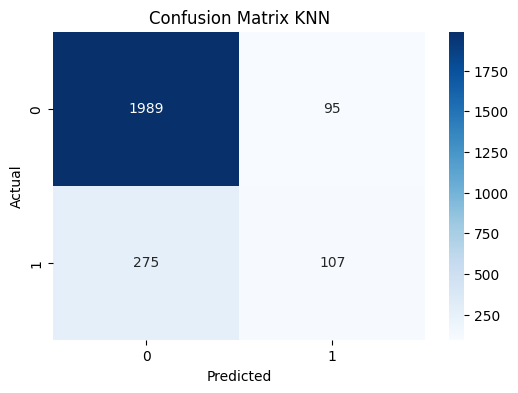

In [54]:
#confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [55]:
#mencari nilai K
k_values = []
accuracy_values = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    k_values.append(k)
    accuracy_values.append(acc)

    print(f"K={k} -> Accuracy={acc:.4f}")

K=1 -> Accuracy=0.8102
K=2 -> Accuracy=0.8536
K=3 -> Accuracy=0.8402
K=4 -> Accuracy=0.8569
K=5 -> Accuracy=0.8500
K=6 -> Accuracy=0.8605
K=7 -> Accuracy=0.8577
K=8 -> Accuracy=0.8597
K=9 -> Accuracy=0.8609
K=10 -> Accuracy=0.8577
K=11 -> Accuracy=0.8581
K=12 -> Accuracy=0.8585
K=13 -> Accuracy=0.8589
K=14 -> Accuracy=0.8593
K=15 -> Accuracy=0.8597
K=16 -> Accuracy=0.8605
K=17 -> Accuracy=0.8601
K=18 -> Accuracy=0.8605
K=19 -> Accuracy=0.8593
K=20 -> Accuracy=0.8597


In [56]:
best_k = k_values[accuracy_values.index(max(accuracy_values))]
best_acc = max(accuracy_values)

print("K Terbaik :", best_k)
print("Accuracy  :", best_acc)

K Terbaik : 9
Accuracy  : 0.8609083536090836


In [57]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred_final = knn_final.predict(X_test)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2084
           1       0.65      0.22      0.33       382

    accuracy                           0.86      2466
   macro avg       0.76      0.60      0.63      2466
weighted avg       0.84      0.86      0.83      2466



In [58]:
joblib.dump(
    knn_final,
    "knn_model.pkl"
)

['knn_model.pkl']

In [59]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']